# svm baseline for figshare bone tumor classification

this notebook trains support vector machine (SVM) classifiers on the BTXRD dataset to serve as a **non-deep-learning baseline** for comparison against the CNN models trained in `baseline_models.ipynb`

**three classification tasks** are run, all using the same train/val split as the CNN notebooks (`test_size=0.2, random_state=42, stratify=y`) so the comparison is apples-to-apples:

1. **tumor vs no tumor** (binary) — matches the CNN target
2. **malignant vs benign** (binary, tumor patients only)
3. **none vs benign vs malignant** (3-class)

**features:** images are loaded in grayscale, resized to 96×96, flattened to 9216-dim vectors, then standardized. SVMs cannot practically handle the 224×224×3 = 150K-dim input the CNNs use, so this downsampling is necessary — and the resulting performance gap is precisely what motivates using CNNs for medical imaging.

**tuning:** each task uses `GridSearchCV` with 5-fold stratified CV over Linear and RBF kernels, varying `C` and `gamma`. The best CV config is refit on the full training set and evaluated on the held-out val set.

In [1]:
import importlib.util
import subprocess
import sys
import time
from pathlib import Path
from typing import Optional

if importlib.util.find_spec("openpyxl") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. paths and configuration

In [2]:
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "data").is_dir():
    REPO_ROOT = Path.cwd().resolve().parent
DATA_ROOT = REPO_ROOT / "data"

BTXRD_ROOT = DATA_ROOT / "BTXRD"
BTXRD_IMAGES = BTXRD_ROOT / "images"
BTXRD_XLSX = BTXRD_ROOT / "dataset.xlsx"

# SVM-specific config:
# 96x96 grayscale -> 9216 features. Bigger than 64x64 (more texture detail), still tractable for an RBF grid search on ~3000 samples (minutes, not hours).
SVM_IMG_SIZE = 96

# 5-fold stratified CV for hyperparameter tuning.
CV_FOLDS = 5

# n_jobs=-1 uses all CPU cores. Set to 1 if you hit memory issues.
N_JOBS = -1

assert BTXRD_IMAGES.is_dir(), f"Missing {BTXRD_IMAGES}"
assert BTXRD_XLSX.is_file(), f"Missing {BTXRD_XLSX}"
print("DATA_ROOT:", DATA_ROOT)
print("SVM image size:", SVM_IMG_SIZE, "->", SVM_IMG_SIZE * SVM_IMG_SIZE, "features")

DATA_ROOT: C:\Users\Constance\Documents\foar skuul frum kani\sem 4 - uh spring 2026\ds2\bone project\data
SVM image size: 96 -> 9216 features


## 2. load tabular labels and resolve image paths

drops any rows whose image file is missing on disk.

In [3]:
def resolve_image_path(images_dir: Path, image_id: str) -> Optional[Path]:
    p = images_dir / str(image_id).strip()
    if p.is_file():
        return p
    stem = Path(str(image_id)).stem
    for ext in (".jpeg", ".jpg", ".png", ".JPEG", ".JPG", ".PNG"):
        c = images_dir / f"{stem}{ext}"
        if c.is_file():
            return c
    return None


btxrd_df = pd.read_excel(BTXRD_XLSX, engine="openpyxl")
btxrd_df.columns = [str(c).strip() for c in btxrd_df.columns]
for needed in ("tumor", "benign", "malignant"):
    if needed not in btxrd_df.columns:
        raise KeyError(f"Expected column '{needed}'; got: {list(btxrd_df.columns)}")

rows = []
for _, r in btxrd_df.iterrows():
    p = resolve_image_path(BTXRD_IMAGES, r["image_id"])
    if p is None:
        continue
    rows.append({
        "path": p.as_posix(),
        "tumor": int(r["tumor"]),
        "benign": int(r["benign"]),
        "malignant": int(r["malignant"]),
    })

df = pd.DataFrame(rows)
print("BTXRD samples with files on disk:", len(df))
print("Tumor rate:    ", df["tumor"].mean().round(4))
print("Benign count:  ", int(df["benign"].sum()))
print("Malignant count:", int(df["malignant"].sum()))
print("None count:    ", int((df["tumor"] == 0).sum()))

BTXRD samples with files on disk: 3746
Tumor rate:     0.4984
Benign count:   1525
Malignant count: 342
None count:     1879


## 3. build feature matrix

Each image is loaded as grayscale, resized to 96×96, flattened to a 9216-vector, and divided by 255. We do this once for all rows so the three classification tasks below can share the same `X`.

In [4]:
def load_image_as_vector(path: str, size: int) -> np.ndarray:
    img = Image.open(path).convert("L").resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32).reshape(-1) / 255.0


t0 = time.time()
X_all = np.empty((len(df), SVM_IMG_SIZE * SVM_IMG_SIZE), dtype=np.float32)
for i, p in enumerate(df["path"].tolist()):
    X_all[i] = load_image_as_vector(p, SVM_IMG_SIZE)
    if (i + 1) % 500 == 0:
        print(f"  loaded {i + 1}/{len(df)}")

print("X_all shape:", X_all.shape, "dtype:", X_all.dtype)
print(f"Loading took {time.time() - t0:.1f}s")

  loaded 500/3746
  loaded 1000/3746
  loaded 1500/3746
  loaded 2000/3746
  loaded 2500/3746
  loaded 3000/3746
  loaded 3500/3746
X_all shape: (3746, 9216) dtype: float32
Loading took 49.3s


## 4. helper: grid-search svm and evaluate on val set

In [5]:
# Parameter grid: 2 kernels x several C values x several gamma values.
# Linear kernel ignores gamma, so gamma values are only meaningful for RBF.
PARAM_GRID = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1.0, 10.0],
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [1.0, 10.0, 100.0],
        "svm__gamma": ["scale", 0.001, 0.01],
    },
]


def grid_search_svm(
    X_train, y_train, X_val, y_val,
    *,
    label: str,
    multiclass: bool = False,
):
    """GridSearch -> refit best -> evaluate on val. Returns results dict."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(random_state=RANDOM_STATE)),
    ])

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(
        pipe,
        PARAM_GRID,
        cv=cv,
        scoring="accuracy",
        n_jobs=N_JOBS,
        verbose=1,
        refit=True,  # refit best on full training set
    )

    n_configs = sum(
        len(g["svm__C"]) * len(g.get("svm__gamma", [None]))
        for g in PARAM_GRID
    )
    print(f"\n{'=' * 70}\n{label}\n{'=' * 70}")
    print(f"  Train shape: {X_train.shape}, Val shape: {X_val.shape}")
    print(f"  Grid: {n_configs} configs x {CV_FOLDS} folds")

    t0 = time.time()
    gs.fit(X_train, y_train)
    elapsed = time.time() - t0

    print(f"\n  Grid search took {elapsed:.1f}s ({elapsed / 60:.1f} min)")
    print(f"  Best CV accuracy: {gs.best_score_:.4f}")
    print(f"  Best params: {gs.best_params_}")

    # Evaluate on held-out validation set
    best = gs.best_estimator_
    y_pred = best.predict(X_val)
    val_acc = accuracy_score(y_val, y_pred)

    # AUC via decision_function. For multiclass, sklearn requires probability-
    # like scores summing to 1, so we softmax the decision scores.
    try:
        scores = best.decision_function(X_val)
        if multiclass:
            ex = np.exp(scores - scores.max(axis=1, keepdims=True))
            probs = ex / ex.sum(axis=1, keepdims=True)
            val_auc = roc_auc_score(y_val, probs, multi_class="ovr", average="macro")
        else:
            val_auc = roc_auc_score(y_val, scores)
    except Exception as e:
        val_auc = float("nan")
        print(f"  (AUC unavailable: {e})")

    print(f"\n  >>> Val accuracy: {val_acc:.4f}")
    print(f"  >>> Val AUC:      {val_auc:.4f}")
    print("\n  Classification report (val):")
    print(classification_report(y_val, y_pred, digits=3))

    return {
        "label": label,
        "best_params": gs.best_params_,
        "cv_accuracy": gs.best_score_,
        "val_accuracy": val_acc,
        "val_auc": val_auc,
        "y_val": y_val,
        "y_pred": y_pred,
        "grid_search": gs,
        "elapsed_seconds": elapsed,
    }


def plot_confusion(result, class_names):
    cm = confusion_matrix(result["y_val"], result["y_pred"])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(result["label"])
    plt.tight_layout()
    plt.show()


def show_grid_results(result, top_n=5):
    """Display the top N configs from the grid search, ranked by CV accuracy."""
    cv_df = pd.DataFrame(result["grid_search"].cv_results_)
    cols = ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    return cv_df[cols].sort_values("rank_test_score").head(top_n).reset_index(drop=True)

## 5. tumor vs no tumor (binary)

Direct comparison to the CNN baselines, which also predict the `tumor` column. Same split (`test_size=0.2, random_state=42, stratify=y`).

In [6]:
y_tumor = df["tumor"].to_numpy(dtype=np.int64)

X_tr1, X_va1, y_tr1, y_va1 = train_test_split(
    X_all, y_tumor,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_tumor,
)
print("Train / Val:", X_tr1.shape, X_va1.shape)

Train / Val: (2996, 9216) (750, 9216)


In [7]:
result_t1 = grid_search_svm(
    X_tr1, y_tr1, X_va1, y_va1,
    label="Task 1: Tumor vs No Tumor",
)


Task 1: Tumor vs No Tumor
  Train shape: (2996, 9216), Val shape: (750, 9216)
  Grid: 12 configs x 5 folds
Fitting 5 folds for each of 12 candidates, totalling 60 fits

  Grid search took 1976.4s (32.9 min)
  Best CV accuracy: 0.6936
  Best params: {'svm__C': 10.0, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

  >>> Val accuracy: 0.7040
  >>> Val AUC:      0.7696

  Classification report (val):
              precision    recall  f1-score   support

           0      0.725     0.660     0.691       376
           1      0.686     0.749     0.716       374

    accuracy                          0.704       750
   macro avg      0.706     0.704     0.703       750
weighted avg      0.706     0.704     0.703       750



In [8]:
print("Top 5 configs by CV accuracy:")
show_grid_results(result_t1)

Top 5 configs by CV accuracy:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'svm__C': 10.0, 'svm__gamma': 'scale', 'svm__...",0.693590,0.013933,1
1,"{'svm__C': 1.0, 'svm__gamma': 'scale', 'svm__k...",0.685911,0.014139,2
2,"{'svm__C': 100.0, 'svm__gamma': 'scale', 'svm_...",0.679243,0.009276,3
3,"{'svm__C': 10.0, 'svm__gamma': 0.001, 'svm__ke...",0.650201,0.004970,4
4,"{'svm__C': 100.0, 'svm__gamma': 0.001, 'svm__k...",0.650201,0.004970,4


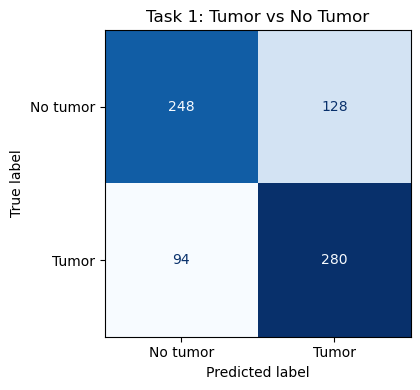

In [9]:
plot_confusion(result_t1, class_names=["No tumor", "Tumor"])

## 6. malignant vs benign (binary, tumor patients only)

Restricted to rows where `tumor == 1`. This is the clinically interesting question: *given* a tumor is present, is it malignant?

In [10]:
tumor_mask = df["tumor"].to_numpy(dtype=bool)
X_tumor = X_all[tumor_mask]
y_mal = df.loc[tumor_mask, "malignant"].to_numpy(dtype=np.int64)

print("Tumor-only samples:", len(y_mal))
print("Malignant rate:    ", y_mal.mean().round(4))

X_tr2, X_va2, y_tr2, y_va2 = train_test_split(
    X_tumor, y_mal,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_mal,
)
print("Train / Val:", X_tr2.shape, X_va2.shape)

Tumor-only samples: 1867
Malignant rate:     0.1832
Train / Val: (1493, 9216) (374, 9216)


In [11]:
result_t2 = grid_search_svm(
    X_tr2, y_tr2, X_va2, y_va2,
    label="Task 2: Malignant vs Benign",
)


Task 2: Malignant vs Benign
  Train shape: (1493, 9216), Val shape: (374, 9216)
  Grid: 12 configs x 5 folds
Fitting 5 folds for each of 12 candidates, totalling 60 fits

  Grid search took 423.9s (7.1 min)
  Best CV accuracy: 0.8339
  Best params: {'svm__C': 10.0, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

  >>> Val accuracy: 0.8128
  >>> Val AUC:      0.7586

  Classification report (val):
              precision    recall  f1-score   support

           0      0.859     0.921     0.889       305
           1      0.489     0.333     0.397        69

    accuracy                          0.813       374
   macro avg      0.674     0.627     0.643       374
weighted avg      0.791     0.813     0.798       374



In [12]:
print("Top 5 configs by CV accuracy:")
show_grid_results(result_t2)

Top 5 configs by CV accuracy:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'svm__C': 10.0, 'svm__gamma': 'scale', 'svm__...",0.833900,0.016659,1
1,"{'svm__C': 100.0, 'svm__gamma': 'scale', 'svm_...",0.833220,0.011699,2
2,"{'svm__C': 1.0, 'svm__gamma': 'scale', 'svm__k...",0.827862,0.007528,3
3,"{'svm__C': 1.0, 'svm__gamma': 0.001, 'svm__ker...",0.817149,0.001342,4
4,"{'svm__C': 10.0, 'svm__gamma': 0.01, 'svm__ker...",0.817149,0.001342,4


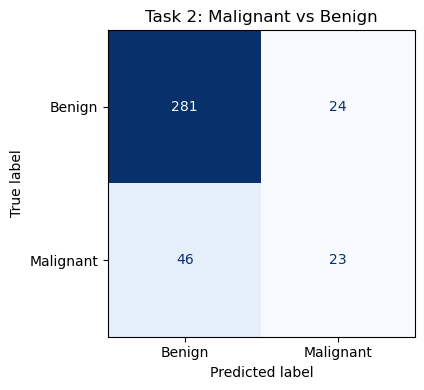

In [13]:
plot_confusion(result_t2, class_names=["Benign", "Malignant"])

## 7. none vs benign vs malignant (3-class)

Single label combining all three:

- `0` = no tumor
- `1` = benign tumor
- `2` = malignant tumor

In [14]:
y_three = np.where(
    df["tumor"] == 0, 0,
    np.where(df["malignant"] == 1, 2, 1),
).astype(np.int64)

print("3-class counts (0=none, 1=benign, 2=malignant):")
print(pd.Series(y_three).value_counts().sort_index())

X_tr3, X_va3, y_tr3, y_va3 = train_test_split(
    X_all, y_three,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_three,
)
print("Train / Val:", X_tr3.shape, X_va3.shape)

3-class counts (0=none, 1=benign, 2=malignant):
0    1879
1    1525
2     342
Name: count, dtype: int64
Train / Val: (2996, 9216) (750, 9216)


In [15]:
result_t3 = grid_search_svm(
    X_tr3, y_tr3, X_va3, y_va3,
    label="Task 3: None vs Benign vs Malignant",
    multiclass=True,
)


Task 3: None vs Benign vs Malignant
  Train shape: (2996, 9216), Val shape: (750, 9216)
  Grid: 12 configs x 5 folds
Fitting 5 folds for each of 12 candidates, totalling 60 fits

  Grid search took 2491.1s (41.5 min)
  Best CV accuracy: 0.6549
  Best params: {'svm__C': 10.0, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

  >>> Val accuracy: 0.6293
  >>> Val AUC:      0.7551

  Classification report (val):
              precision    recall  f1-score   support

           0      0.664     0.684     0.674       376
           1      0.596     0.649     0.622       305
           2      0.548     0.246     0.340        69

    accuracy                          0.629       750
   macro avg      0.603     0.526     0.545       750
weighted avg      0.626     0.629     0.622       750



In [16]:
print("Top 5 configs by CV accuracy:")
show_grid_results(result_t3)

Top 5 configs by CV accuracy:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'svm__C': 10.0, 'svm__gamma': 'scale', 'svm__...",0.654874,0.013889,1
1,"{'svm__C': 1.0, 'svm__gamma': 'scale', 'svm__k...",0.637183,0.011825,2
2,"{'svm__C': 100.0, 'svm__gamma': 'scale', 'svm_...",0.628175,0.011209,3
3,"{'svm__C': 10.0, 'svm__gamma': 0.001, 'svm__ke...",0.609472,0.011969,4
4,"{'svm__C': 100.0, 'svm__gamma': 0.001, 'svm__k...",0.609472,0.011969,4


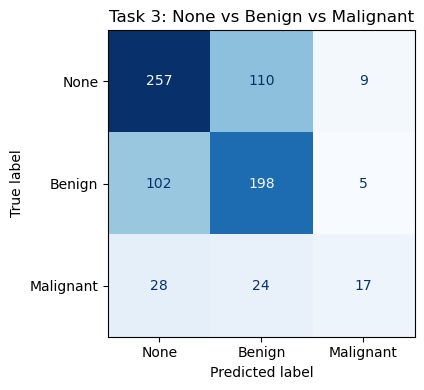

In [17]:
plot_confusion(result_t3, class_names=["None", "Benign", "Malignant"])

## 8. summary table

All three tuned SVMs in one place. Compare **Task 1 val_accuracy and val_auc** to the values printed at the bottom of `baseline_models.ipynb` (`val_accuracy`, `val_auc`) — that's the headline CNN-vs-SVM number.

In [18]:
all_results = [result_t1, result_t2, result_t3]
summary_df = pd.DataFrame([
    {
        "task": r["label"],
        "best_kernel": r["best_params"].get("svm__kernel"),
        "best_C": r["best_params"].get("svm__C"),
        "best_gamma": r["best_params"].get("svm__gamma", "-"),
        "cv_accuracy": round(r["cv_accuracy"], 4),
        "val_accuracy": round(r["val_accuracy"], 4),
        "val_auc": round(r["val_auc"], 4),
        "runtime_min": round(r["elapsed_seconds"] / 60, 1),
    }
    for r in all_results
])
summary_df

,task,best_kernel,best_C,best_gamma,cv_accuracy,val_accuracy,val_auc,runtime_min
0,Task 1: Tumor vs No Tumor,rbf,10.0,scale,0.6936,0.7040,0.7696,32.9
1,Task 2: Malignant vs Benign,rbf,10.0,scale,0.8339,0.8128,0.7586,7.1
2,Task 3: None vs Benign vs Malignant,rbf,10.0,scale,0.6549,0.6293,0.7551,41.5
